Taken over from:

Fouilloux, A. (2026). EarthCARE to DGGS (v0.1.0). Zenodo.
https://doi.org/10.5281/zenodo.19709327

# ATLID/CPR Profiles to HEALPix

Convert EarthCARE atmospheric profile data (ATLID lidar, CPR radar) to HEALPix.

Profile data is fundamentally different from 2D swath imagery:
- 1D lat/lon along the ground track
- A vertical dimension (height) with atmospheric columns
- Each profile is mapped to a HEALPix cell, the vertical axis is preserved

In [1]:
import earthcarekit as eck
import healpix_geo as hpxg
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from earthcare_dggs.convert import lonlat_to_healpix_cells
from earthcare_dggs.settings import ATLID_DEPTH, ELLIPSOID

ORBIT = "06109D"

## Load ATLID product

In [2]:
result = eck.search_product(file_type="ATL_AER_2A", orbit_and_frame=ORBIT)
with eck.read_product(result.filepath[0]) as ds:
    atl = ds.load()

print(f"Dimensions: {dict(atl.sizes)}")
print(f"Lat: [{float(atl['latitude'].min()):.1f}, {float(atl['latitude'].max()):.1f}]")
print(f"Lon: [{float(atl['longitude'].min()):.1f}, {float(atl['longitude'].max()):.1f}]")
print(f"\n2D variables (along_track, vertical):")
for v in atl.data_vars:
    if atl[v].dims == ("along_track", "vertical"):
        print(f"  {v}: shape={atl[v].shape}")

Dimensions: {'along_track': 5144, 'vertical': 242, 'layer': 25, 'class': 7}
Lat: [22.5, 67.5]
Lon: [-0.6, 16.7]

2D variables (along_track, vertical):
  height: shape=(5144, 242)
  range: shape=(5144, 242)
  simple_classification: shape=(5144, 242)
  mie_detection_status: shape=(5144, 242)
  rayleigh_detection_status: shape=(5144, 242)
  horizontal_averaging_mask: shape=(5144, 242)
  internal_lidar_feature_mask: shape=(5144, 242)
  extended_data_quality_status: shape=(5144, 242)
  quality_status: shape=(5144, 242)
  particle_extinction_coefficient_355nm: shape=(5144, 242)
  particle_extinction_coefficient_355nm_error: shape=(5144, 242)
  particle_backscatter_coefficient_355nm: shape=(5144, 242)
  particle_backscatter_coefficient_355nm_error: shape=(5144, 242)
  particle_linear_depol_ratio_355nm: shape=(5144, 242)
  particle_linear_depol_ratio_355nm_error: shape=(5144, 242)
  lidar_ratio_355nm: shape=(5144, 242)
  lidar_ratio_355nm_error: shape=(5144, 242)
  particle_effective_area_radi

## Assign HEALPix cell IDs

For profile data, we assign each along-track position to its HEALPix cell
and add `cell_ids` as a coordinate. The vertical dimension is preserved as-is.

In [3]:
prof_cell_ids = lonlat_to_healpix_cells(
    atl["longitude"].values, atl["latitude"].values,
    depth=ATLID_DEPTH, ellipsoid=ELLIPSOID,
)

unique_cells = np.unique(prof_cell_ids)
print(f"HEALPix depth {ATLID_DEPTH}: {len(atl.along_track)} profiles → {len(unique_cells)} unique cells")
print(f"Average profiles per cell: {len(atl.along_track) / len(unique_cells):.1f}")

# Add cell_ids as coordinate
atl_healpix = atl.assign_coords(cell_ids=("along_track", prof_cell_ids))
atl_healpix.attrs.update({
    "healpix_level": ATLID_DEPTH,
    "healpix_indexing": "nested",
    "healpix_ellipsoid": ELLIPSOID,
})

print(f"\nDataset with cell_ids coordinate:")
print(atl_healpix)

HEALPix depth 14: 5144 profiles → 5144 unique cells
Average profiles per cell: 1.0

Dataset with cell_ids coordinate:
<xarray.Dataset> Size: 100MB
Dimensions:                                       (along_track: 5144,
                                                   vertical: 242, layer: 25,
                                                   class: 7)
Coordinates:
    cell_ids                                      (along_track) uint64 41kB 2...
Dimensions without coordinates: along_track, vertical, layer, class
Data variables: (12/48)
    filename                                      <U60 240B 'ECA_EXBA_ATL_AER...
    file_type                                     <U10 40B 'ATL_AER_2A'
    frame_id                                      <U1 4B 'D'
    orbit_number                                  int64 8B 6109
    orbit_and_frame                               <U6 24B '06109D'
    baseline                                      <U2 8B 'BA'
    ...                                            .

In [4]:
atl_healpix

<xarray.Dataset> Size: 100MB
Dimensions:                                       (along_track: 5144,
                                                   vertical: 242, layer: 25,
                                                   class: 7)
Coordinates:
    cell_ids                                      (along_track) uint64 41kB 2...
Dimensions without coordinates: along_track, vertical, layer, class
Data variables: (12/48)
    filename                                      <U60 240B 'ECA_EXBA_ATL_AER...
    file_type                                     <U10 40B 'ATL_AER_2A'
    frame_id                                      <U1 4B 'D'
    orbit_number                                  int64 8B 6109
    orbit_and_frame                               <U6 24B '06109D'
    baseline                                      <U2 8B 'BA'
    ...                                            ...
    classification                                (along_track, vertical) int8 1MB ...
    aerosol_classification                        (along_track, vertical) int8 1MB ...
    aerosol_classification_no_error               (along_track, vertical) int8 1MB ...
    aerosol_classes                               (class) |S32 224B b'  1: Du...
    aerosol_classification_prob                   (along_track, vertical, class) int8 9MB ...
    aerosol_classification_prob_no_errors         (along_track, vertical, class) int8 9MB ...
Attributes:
    healpix_level:      14
    healpix_indexing:   nested
    healpix_ellipsoid:  WGS84

## Visualize

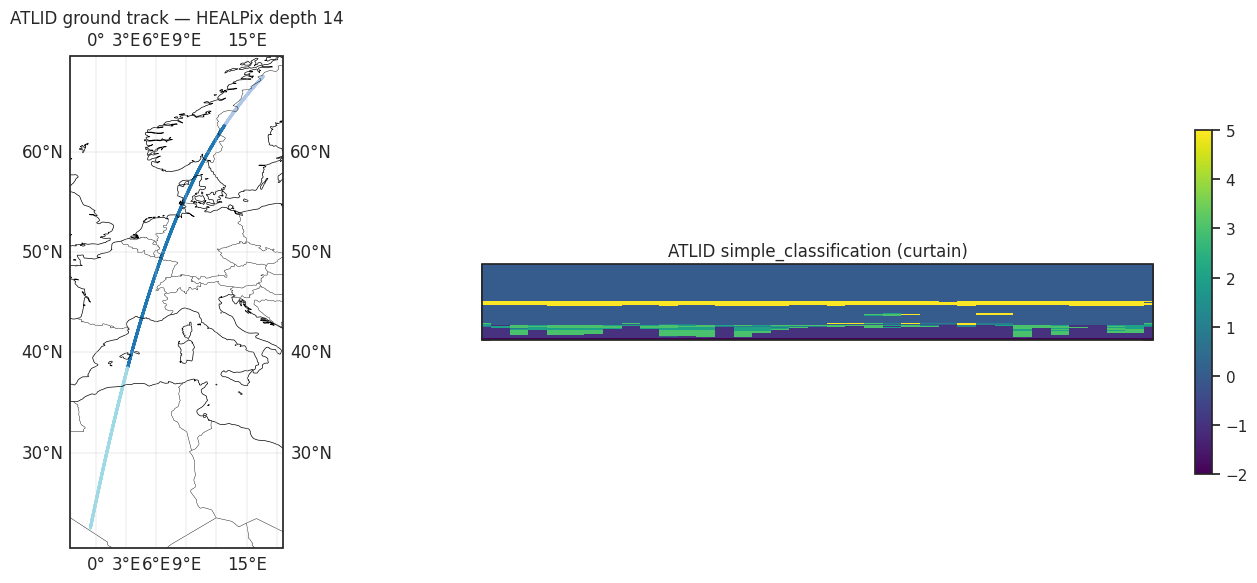

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         subplot_kw={"projection": ccrs.PlateCarree()},
                         gridspec_kw={"width_ratios": [1, 1]})

# Ground track colored by HEALPix cell
ax = axes[0]
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3)
sc = ax.scatter(
    atl["longitude"].values, atl["latitude"].values,
    c=prof_cell_ids, s=1, cmap="tab20",
    transform=ccrs.PlateCarree(),
)
ax.set_title(f"ATLID ground track — HEALPix depth {ATLID_DEPTH}")
ax.set_extent([
    float(atl.longitude.min()) - 2, float(atl.longitude.max()) + 2,
    float(atl.latitude.min()) - 2, float(atl.latitude.max()) + 2,
], crs=ccrs.PlateCarree())

# Curtain plot — find first 2D variable
ax = axes[1]
plot_var = None
for v in atl.data_vars:
    if atl[v].dims == ("along_track", "vertical") and v not in ("height", "range"):
        plot_var = v
        break

if plot_var and "height" in atl:
    data = atl[plot_var].values
    height = atl["height"].values / 1000  # km
    step = max(1, data.shape[0] // 500)
    im = ax.pcolormesh(
        np.arange(0, data.shape[0], step),
        height[::step, :].T,
        data[::step, :].T,
        shading="nearest", cmap="viridis",
    )
    ax.set_xlabel("Along-track index")
    ax.set_ylabel("Height (km)")
    ax.set_title(f"ATLID {plot_var} (curtain)")
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

## Groupby cell for aggregation

With `cell_ids` as a coordinate, you can easily aggregate profiles per cell
using xarray's `groupby`.

In [6]:
# Example: compute mean profile per HEALPix cell
if plot_var:
    cell_mean = atl_healpix[plot_var].groupby("cell_ids").mean()
    print(f"Mean {plot_var} per cell: {cell_mean}")

Mean simple_classification per cell: <xarray.DataArray 'simple_classification' (cell_ids: 5144, vertical: 242)> Size: 10MB
array([[ 0.,  0.,  0., ..., -2., -2., -2.],
       [ 0.,  0.,  0., ..., -2., -2., -2.],
       [ 0.,  0.,  0., ..., -2., -2., -2.],
       ...,
       [ 0.,  0.,  0., ..., -2., -2., -2.],
       [ 0.,  0.,  0., ..., -2., -2., -2.],
       [ 0.,  0.,  0., ..., -2., -2., -2.]], shape=(5144, 242))
Coordinates:
  * cell_ids  (cell_ids) uint64 41kB 176849026 176849036 ... 1340069332
Dimensions without coordinates: vertical
Attributes:
    units:       1
    long_name:   Simple Classification
    comment:     Simple Classification (used as backup if A-TC class if unknown)
    definition:  -3: Missing data \n\t-2: Surface \n\t-1: BOTH Mie and Ray At...


In [7]:
atl_healpix

<xarray.Dataset> Size: 100MB
Dimensions:                                       (along_track: 5144,
                                                   vertical: 242, layer: 25,
                                                   class: 7)
Coordinates:
    cell_ids                                      (along_track) uint64 41kB 2...
Dimensions without coordinates: along_track, vertical, layer, class
Data variables: (12/48)
    filename                                      <U60 240B 'ECA_EXBA_ATL_AER...
    file_type                                     <U10 40B 'ATL_AER_2A'
    frame_id                                      <U1 4B 'D'
    orbit_number                                  int64 8B 6109
    orbit_and_frame                               <U6 24B '06109D'
    baseline                                      <U2 8B 'BA'
    ...                                            ...
    classification                                (along_track, vertical) int8 1MB ...
    aerosol_classification                        (along_track, vertical) int8 1MB ...
    aerosol_classification_no_error               (along_track, vertical) int8 1MB ...
    aerosol_classes                               (class) |S32 224B b'  1: Du...
    aerosol_classification_prob                   (along_track, vertical, class) int8 9MB ...
    aerosol_classification_prob_no_errors         (along_track, vertical, class) int8 9MB ...
Attributes:
    healpix_level:      14
    healpix_indexing:   nested
    healpix_ellipsoid:  WGS84